In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, ConfusionMatrixDisplay
)
from sklearn.preprocessing import LabelEncoder

import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
print("✅ Libraries imported successfully")

✅ Libraries imported successfully


In [7]:
df = pd.read_csv("/content/student_performance.csv")

df.head()

,StudyHours,Attendance,Resources,Extracurricular,Motivation,Internet,Gender,Age,LearningStyle,OnlineCourses,Discussions,AssignmentCompletion,ExamScore,EduTech,StressLevel,FinalGrade
0,19,64,1,0,0,1,0,19,2,8,1,59,40,0,1,3
1,19,64,1,0,0,1,0,23,3,16,0,90,66,0,1,2
2,19,64,1,0,0,1,0,28,1,19,0,67,99,1,1,0
3,19,64,1,1,0,1,0,19,2,8,1,59,40,0,1,3
4,19,64,1,1,0,1,0,23,3,16,0,90,66,0,1,2


In [8]:
print("Rows and Columns:")
print(df.shape)

Rows and Columns:
(14003, 16)


In [9]:
print(df.columns)

Index(['StudyHours', 'Attendance', 'Resources', 'Extracurricular',
       'Motivation', 'Internet', 'Gender', 'Age', 'LearningStyle',
       'OnlineCourses', 'Discussions', 'AssignmentCompletion', 'ExamScore',
       'EduTech', 'StressLevel', 'FinalGrade'],
      dtype='object')


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14003 entries, 0 to 14002
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   StudyHours            14003 non-null  int64
 1   Attendance            14003 non-null  int64
 2   Resources             14003 non-null  int64
 3   Extracurricular       14003 non-null  int64
 4   Motivation            14003 non-null  int64
 5   Internet              14003 non-null  int64
 6   Gender                14003 non-null  int64
 7   Age                   14003 non-null  int64
 8   LearningStyle         14003 non-null  int64
 9   OnlineCourses         14003 non-null  int64
 10  Discussions           14003 non-null  int64
 11  AssignmentCompletion  14003 non-null  int64
 12  ExamScore             14003 non-null  int64
 13  EduTech               14003 non-null  int64
 14  StressLevel           14003 non-null  int64
 15  FinalGrade            14003 non-null  int64
dtypes: i

In [11]:
df.isnull().sum()

,0
StudyHours,0
Attendance,0
Resources,0
Extracurricular,0
Motivation,0
Internet,0
Gender,0
Age,0
LearningStyle,0
OnlineCourses,0


In [12]:
duplicate_count = df.duplicated().sum()

print("Duplicate Rows:", duplicate_count)

duplicate_percentage = (duplicate_count / len(df)) * 100

print("Percentage of Duplicates:", round(duplicate_percentage,2), "%")

Duplicate Rows: 1534
Percentage of Duplicates: 10.95 %


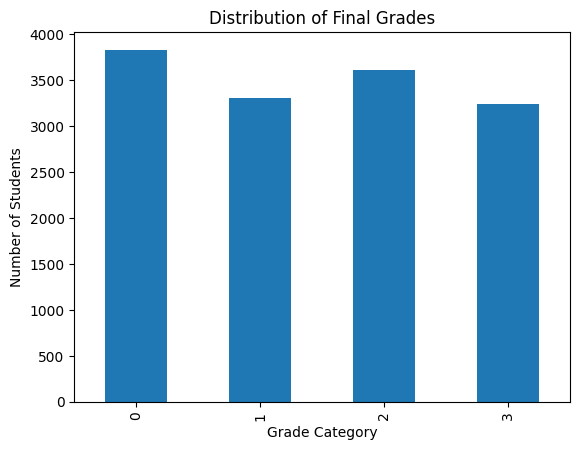

In [13]:
df["FinalGrade"].value_counts().sort_index().plot(kind="bar")

plt.title("Distribution of Final Grades")
plt.xlabel("Grade Category")
plt.ylabel("Number of Students")

plt.show()

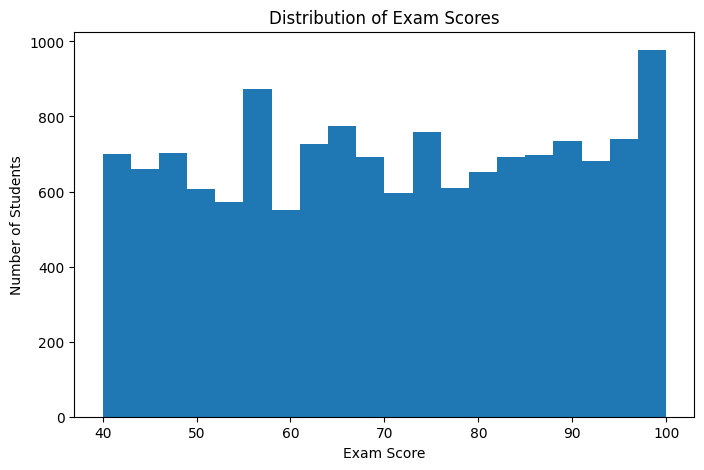

In [14]:
plt.figure(figsize=(8,5))
plt.hist(df["ExamScore"], bins=20)
plt.title("Distribution of Exam Scores")
plt.xlabel("Exam Score")
plt.ylabel("Number of Students")
plt.show()

In [15]:
corr = df.corr(numeric_only=True)

corr["FinalGrade"].sort_values(ascending=False)

,FinalGrade
FinalGrade,1.000000
Discussions,0.039741
StressLevel,0.037786
Attendance,0.010870
Extracurricular,0.010560
Internet,0.006345
Age,0.002903
Motivation,0.002726
Resources,-0.002907
StudyHours,-0.009623


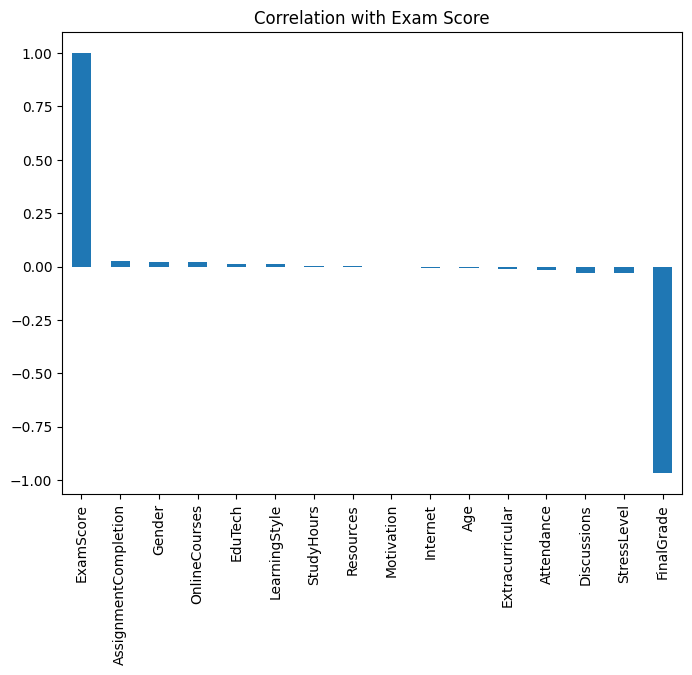

In [16]:
import matplotlib.pyplot as plt

corr_exam = corr["ExamScore"].sort_values(ascending=False)

plt.figure(figsize=(8,6))
corr_exam.plot(kind="bar")
plt.title("Correlation with Exam Score")
plt.show()

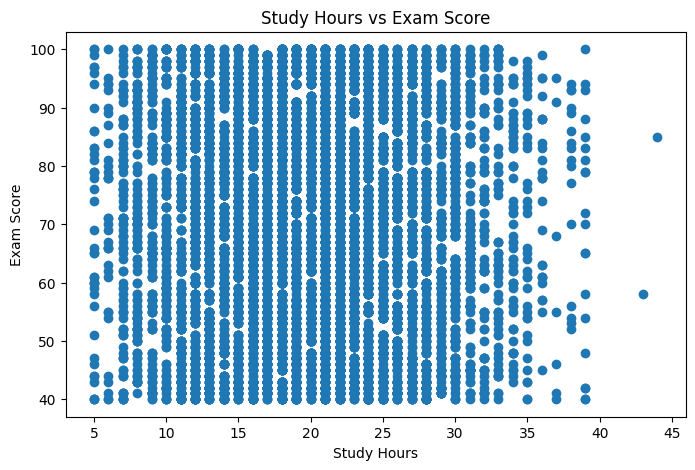

In [17]:
plt.figure(figsize=(8,5))

plt.scatter(df["StudyHours"], df["ExamScore"])

plt.xlabel("Study Hours")
plt.ylabel("Exam Score")
plt.title("Study Hours vs Exam Score")

plt.show()

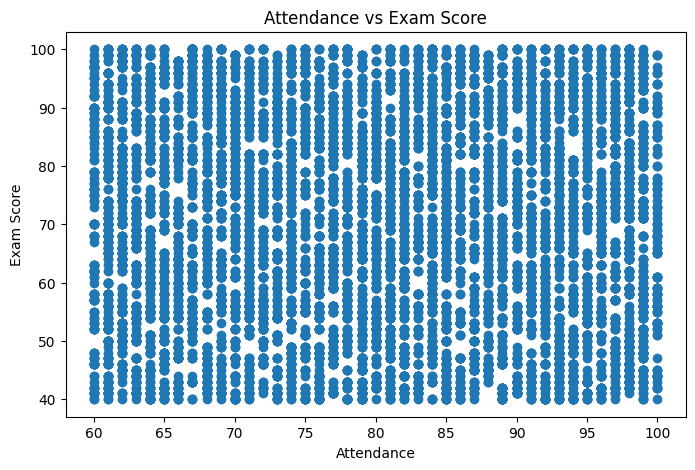

In [18]:
plt.figure(figsize=(8,5))

plt.scatter(df["Attendance"], df["ExamScore"])

plt.xlabel("Attendance")
plt.ylabel("Exam Score")
plt.title("Attendance vs Exam Score")

plt.show()

In [19]:
df["FinalGrade"].value_counts().sort_index()

,count
FinalGrade,
0,3832
1,3310
2,3618
3,3243


In [20]:
# 2a. Remove duplicates
before = len(df)
df = df.drop_duplicates()
after = len(df)
print(f"\n✅ Duplicates removed: {before - after:,} rows dropped → {after:,} records remain")


✅ Duplicates removed: 1,534 rows dropped → 12,469 records remain


In [21]:
# 2b. Check missing values
print("\n📋 Missing values per column:")
print(df.isnull().sum())

# 2c. Confirm column names (adjust if your CSV uses different names)
print("\n📋 Columns:", df.columns.tolist())


📋 Missing values per column:
StudyHours              0
Attendance              0
Resources               0
Extracurricular         0
Motivation              0
Internet                0
Gender                  0
Age                     0
LearningStyle           0
OnlineCourses           0
Discussions             0
AssignmentCompletion    0
ExamScore               0
EduTech                 0
StressLevel             0
FinalGrade              0
dtype: int64

📋 Columns: ['StudyHours', 'Attendance', 'Resources', 'Extracurricular', 'Motivation', 'Internet', 'Gender', 'Age', 'LearningStyle', 'OnlineCourses', 'Discussions', 'AssignmentCompletion', 'ExamScore', 'EduTech', 'StressLevel', 'FinalGrade']


In [22]:
# ── 3. Feature Selection ──────────────────────────────────────────────────────
# IMPORTANT: ExamScore is EXCLUDED to prevent data leakage.
# FinalGrade (r = -0.97 with ExamScore) would cause the model to learn
# the derived relationship, not genuine behavioural patterns.

TARGET = "FinalGrade"


In [23]:
# Exclude ExamScore AND the target itself from features
EXCLUDE = [TARGET, "ExamScore"]
FEATURES = [col for col in df.columns if col not in EXCLUDE]

print(f"\n✅ Target variable: {TARGET}")
print(f"✅ Features used ({len(FEATURES)}): {FEATURES}")
print(f"⚠️  Excluded (data leakage prevention): ExamScore")

X = df[FEATURES]
y = df[TARGET]

print(f"\n📋 Target class distribution:")
print(y.value_counts().sort_index())



✅ Target variable: FinalGrade
✅ Features used (14): ['StudyHours', 'Attendance', 'Resources', 'Extracurricular', 'Motivation', 'Internet', 'Gender', 'Age', 'LearningStyle', 'OnlineCourses', 'Discussions', 'AssignmentCompletion', 'EduTech', 'StressLevel']
⚠️  Excluded (data leakage prevention): ExamScore

📋 Target class distribution:
FinalGrade
0    3401
1    2943
2    3221
3    2904
Name: count, dtype: int64


In [29]:
# ── 4. Train / Test Split ─────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\n✅ Train set: {len(X_train):,} | Test set: {len(X_test):,}")


✅ Train set: 9,975 | Test set: 2,494


In [30]:
# ── 5. Train Random Forest ────────────────────────────────────────────────────
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
print("✅ Random Forest model trained")

✅ Random Forest model trained


In [31]:
# ── 6. Evaluate ───────────────────────────────────────────────────────────────
y_pred = rf.predict(X_test)
acc    = accuracy_score(y_test, y_pred)

print(f"\n🎯 Accuracy: {acc:.4f}  ({acc*100:.2f}%)")
print("\n📋 Classification Report:")
print(classification_report(y_test, y_pred))


🎯 Accuracy: 0.9042  (90.42%)

📋 Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.92      0.90       680
           1       0.91      0.87      0.89       589
           2       0.90      0.91      0.91       644
           3       0.94      0.91      0.93       581

    accuracy                           0.90      2494
   macro avg       0.91      0.90      0.90      2494
weighted avg       0.90      0.90      0.90      2494



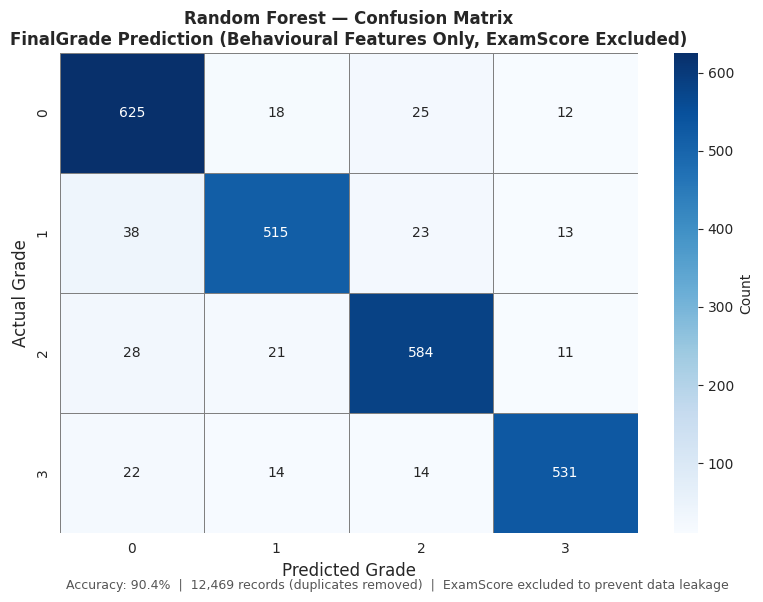

✅ Saved: confusion_matrix.png


In [32]:
# ── 7. Confusion Matrix ───────────────────────────────────────────────────────
grade_labels = sorted(y.unique())
cm = confusion_matrix(y_test, y_pred, labels=grade_labels)

fig1, ax1 = plt.subplots(figsize=(8, 6))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=grade_labels, yticklabels=grade_labels,
    linewidths=0.5, linecolor="gray", ax=ax1,
    cbar_kws={"label": "Count"}
)
ax1.set_xlabel("Predicted Grade", fontsize=12)
ax1.set_ylabel("Actual Grade",    fontsize=12)
ax1.set_title(
    "Random Forest — Confusion Matrix\n"
    "FinalGrade Prediction (Behavioural Features Only, ExamScore Excluded)",
    fontsize=12, fontweight="bold"
)
fig1.text(
    0.5, 0.01,
    f"Accuracy: {acc:.1%}  |  {after:,} records (duplicates removed)  |  ExamScore excluded to prevent data leakage",
    ha="center", fontsize=9, color="#555555"
)
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved: confusion_matrix.png")


📋 Feature Importances:
             Feature  Importance
AssignmentCompletion    0.160075
          Attendance    0.150843
          StudyHours    0.142141
       OnlineCourses    0.139410
                 Age    0.118146
       LearningStyle    0.068746
         StressLevel    0.046004
              Gender    0.031497
             EduTech    0.030639
           Resources    0.029331
          Motivation    0.027999
         Discussions    0.026954
     Extracurricular    0.018929
            Internet    0.009285


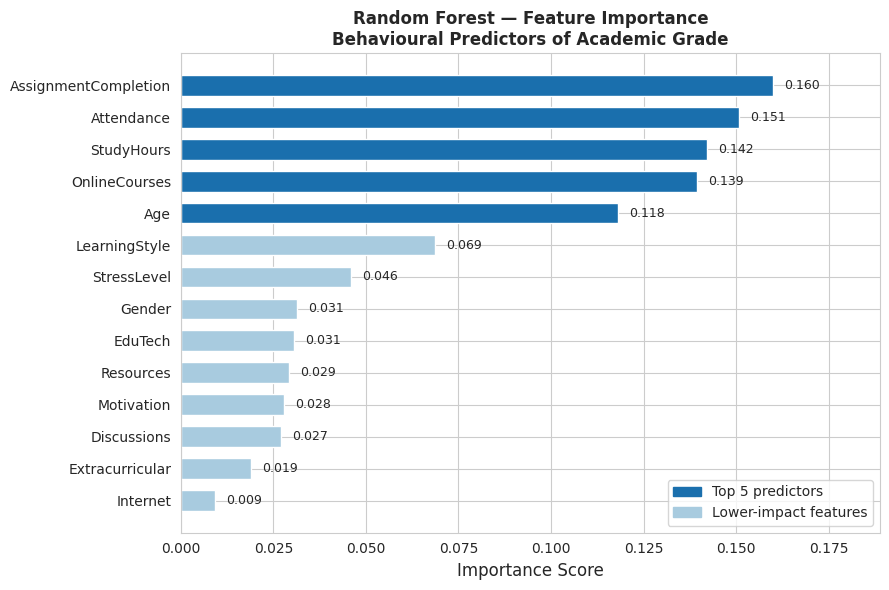

✅ Saved: feature_importance.png


In [37]:
# ── 8. Feature Importance ─────────────────────────────────────────────────────
feat_imp = pd.DataFrame({
    "Feature":    FEATURES,
    "Importance": rf.feature_importances_
}).sort_values("Importance", ascending=False)

print("\n📋 Feature Importances:")
print(feat_imp.to_string(index=False))

colours = ["#1a6fad" if i < 5 else "#a8cbdf" for i in range(len(feat_imp))]

fig2, ax2 = plt.subplots(figsize=(9, 6))
ax2.barh(feat_imp["Feature"][::-1], feat_imp["Importance"][::-1],
         color=colours[::-1], edgecolor="white", height=0.65)
for i, val in enumerate(feat_imp["Importance"][::-1]):
    ax2.text(val + 0.003, i, f"{val:.3f}", va="center", fontsize=9)

ax2.set_xlabel("Importance Score", fontsize=12)
ax2.set_title(
    "Random Forest — Feature Importance\n"
    "Behavioural Predictors of Academic Grade",
    fontsize=12, fontweight="bold"
)
ax2.set_xlim(0, feat_imp["Importance"].max() * 1.18)
ax2.legend(
    handles=[
        mpatches.Patch(color="#1a6fad", label="Top 5 predictors"),
        mpatches.Patch(color="#a8cbdf", label="Lower-impact features"),
    ],
    loc="lower right", fontsize=10
)
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved: feature_importance.png")